# Import dependencies

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics


In [15]:
!pip install xgboost

# Data Collection & Proecessing

In [16]:
calories = pd.read_csv('calories.csv')
excerise_data = pd.read_csv('exercise.csv')

In [ ]:
calories_data = pd.concat([excerise_data, calories['Calories']], axis=1)
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [18]:
calories_data.shape

(15000, 9)

# Data Analysis

In [19]:
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# Data Vistulization

In [20]:
sns.set()

<Axes: xlabel='Gender', ylabel='count'>

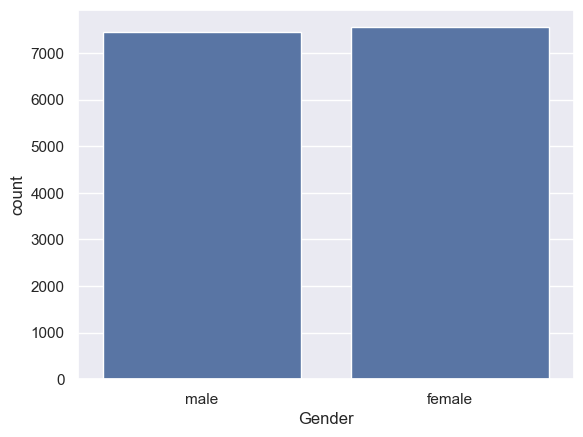

In [21]:
sns.countplot(x='Gender', data=calories_data)

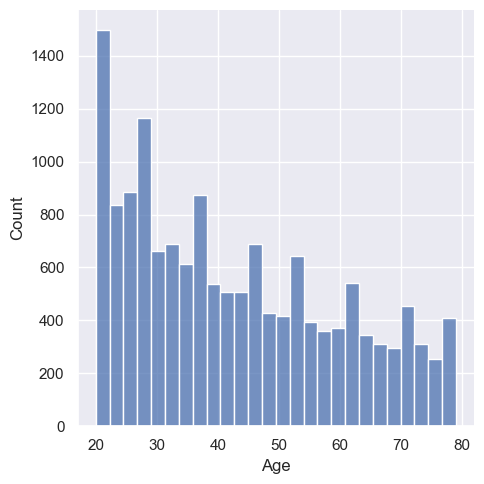

In [22]:
sns.displot(calories_data['Age'])

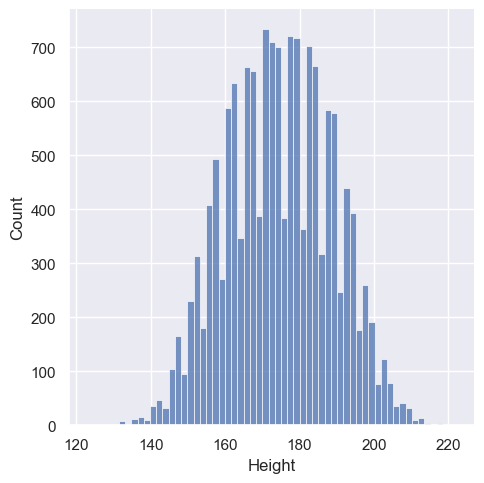

In [23]:
sns.displot(calories_data['Height'])

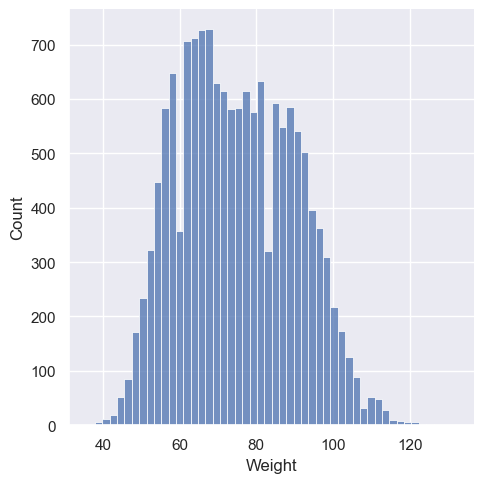

In [24]:
sns.displot(calories_data['Weight'])

In [27]:
calories_data.replace({"Gender":{"male":0,"female":1}}, inplace=True)

/var/folders/yc/6x1zzk917rz40_9mncz_bhd00000gn/T/ipykernel_1797/3338304186.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  calories_data.replace({"Gender":{"male":0,"female":1}}, inplace=True)


In [28]:
correlation = calories_data.corr()

<Axes: >

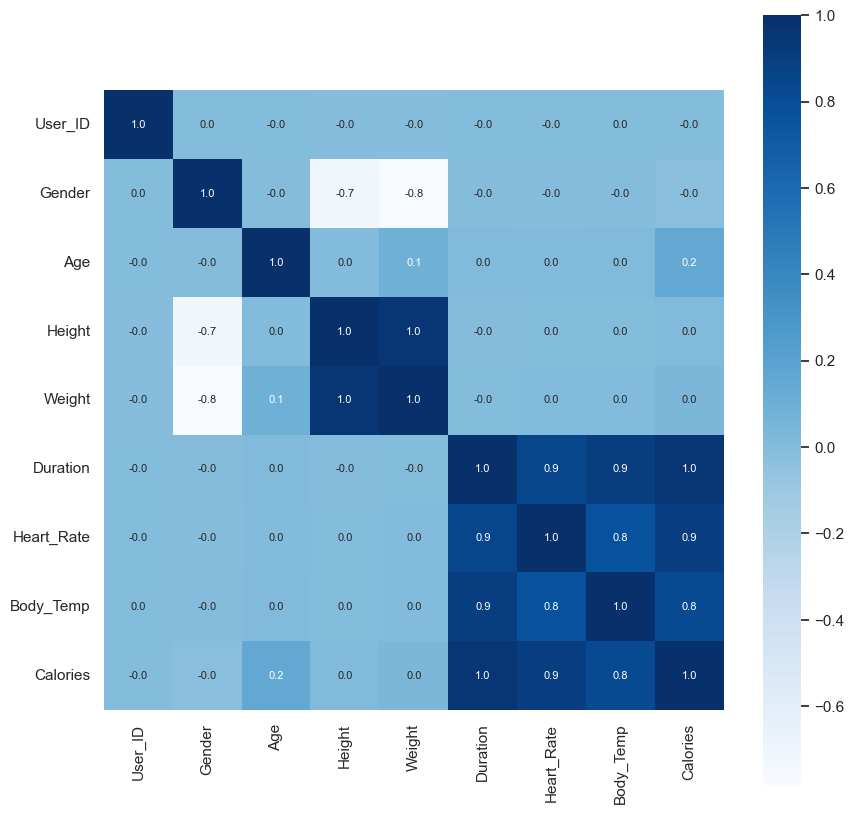

In [29]:
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size': 8}, cmap='Blues')

In [33]:
X = calories_data.drop(columns=['User_ID','Calories'], axis=1)
Y = calories_data['Calories']

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [35]:
print(X.shape, X_train.shape, X_test.shape)

(15000, 7) (12000, 7) (3000, 7)


In [36]:
model = XGBRegressor()
model.fit(X_train, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [37]:
test_data_prediction = model.predict(X_test)

In [38]:
print(test_data_prediction)

[125.58828  222.11377   38.725952 ... 144.3179    23.425894  90.100494]


In [39]:
#mean absolte error
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
print("Mean Absolute Error : ", mae)

Mean Absolute Error :  1.4833678883314132


## Building Predicitive System

In [44]:
input_data = (0,25,175,70,30,110,40)
#change the input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)
#reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
#standardize the input data
prediction = model.predict(input_data_reshaped)
#print the prediction
print("Predicted Calories Burned:", prediction)

Predicted Calories Burned: [184.24066]


In [41]:
print(X)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [45]:
import pickle

# save the trained model
pickle.dump(model, open("calories_model.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


In [46]:
import os
os.listdir()

['001.ipynb', 'exercise.csv', 'calories.csv', 'calories_model.pkl']